<a href="https://colab.research.google.com/github/DinaKSari/PCVK_2026_2027/blob/main/week6_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
NAMA = 'DINA KUMALA SARI'
NIM  = '244107020072'
print(NAMA, NIM)

DINA KUMALA SARI 244107020072


# D PRAKTIKUM FILTER

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [29]:
# FUNGSI KONVOLUSI TANPA KERNEL
def convolution2d(image, kernel, stride, padding):
    image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    kh, kw = kernel.shape
    ih, iw = image.shape
    oh = (ih - kh) // stride + 1
    ow = (iw - kw) // stride + 1
    output = np.zeros((oh, ow))
    for y in range(oh):
        for x in range(ow):
            region = image[y*stride:y*stride+kh, x*stride:x*stride+kw]
            output[y, x] = np.sum(region * kernel)
    return np.clip(output, 0, 255).astype(np.uint8)

### load citra

In [30]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

### Kernel Sharpen & Panggil Fungsi

In [31]:
#image sharpen
kernel_sharpen = np.array([[0,-1,0],
                            [-1,5,-1],
                            [0,-1,0]])

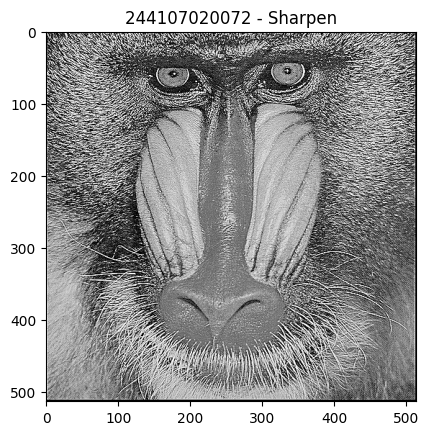

In [32]:
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Sharpen')
plt.show()

### 3 Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter

### sharpen filter

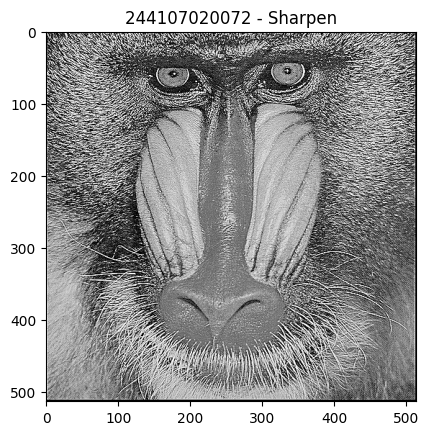

In [33]:
#image sharpen
kernel_sharpen = np.array([[0,-1,0],
                            [-1,5,-1],
                            [0,-1,0]])

hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Sharpen')
plt.show()

### emboss filter

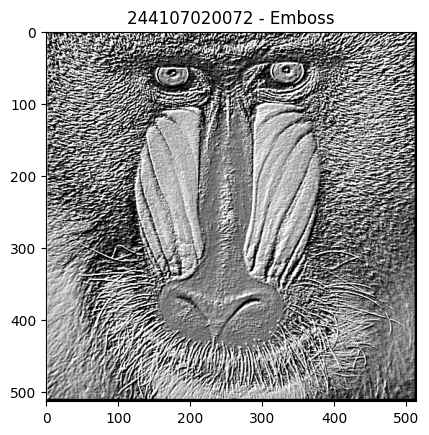

In [34]:
kernel_emboss = np.array([[-2,-1,0],
                           [-1,1,1],
                           [0,1,2]])
hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 2)
plt.imshow(hasil_emboss, cmap='gray')
plt.title(NIM + ' - Emboss')
plt.show()

### Left Sobel Edge Detection filter

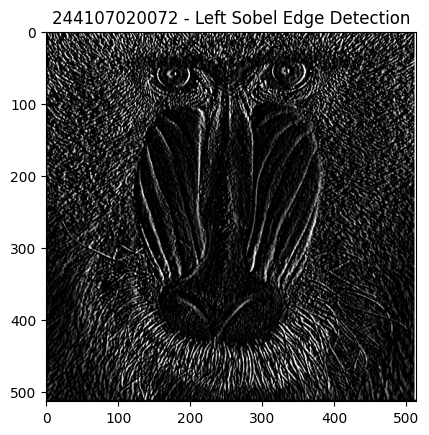

In [35]:
kernel_left_sobel = np.array([[1,0,-1],
                               [2,0,-2],
                               [1,0,-1]])
hasil_left_sobel = convolution2d(img_gray, kernel_left_sobel, 1, 2)
plt.imshow(hasil_left_sobel, cmap='gray')
plt.title(NIM + ' - Left Sobel Edge Detection')
plt.show()

### Canny Edge Detection filter

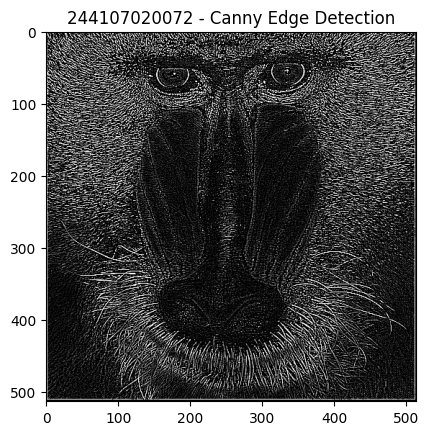

In [36]:
kernel_canny = np.array([[-1,-1,-1],
                          [-1,8,-1],
                          [-1,-1,-1]])
hasil_canny = convolution2d(img_gray, kernel_canny, 1, 2)
plt.imshow(hasil_canny, cmap='gray')
plt.title(NIM + ' - Canny Edge Detection')
plt.show()

### 21x21 Gaussian Blur

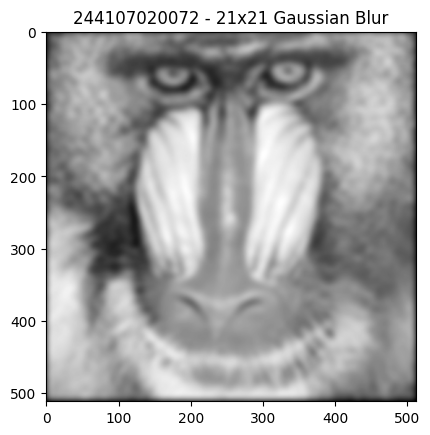

In [37]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
hasil_gauss = convolution2d(img_gray, gauss_kernel, 1, 10)
plt.imshow(hasil_gauss, cmap='gray')
plt.title(NIM + ' - 21x21 Gaussian Blur')
plt.show()

# E1

### Percobaan 1

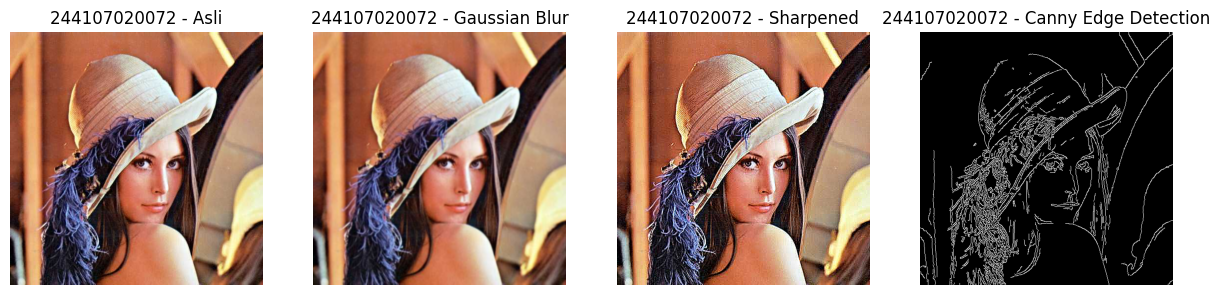

In [38]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img_, title) in enumerate(zip(images, titles)):
        if len(img_.shape) == 2:
            plt.subplot(1, len(images), i+1)
            plt.imshow(img_, cmap="gray")
        else:
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img_, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK/Images/244107020072/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

### Percobaan 2

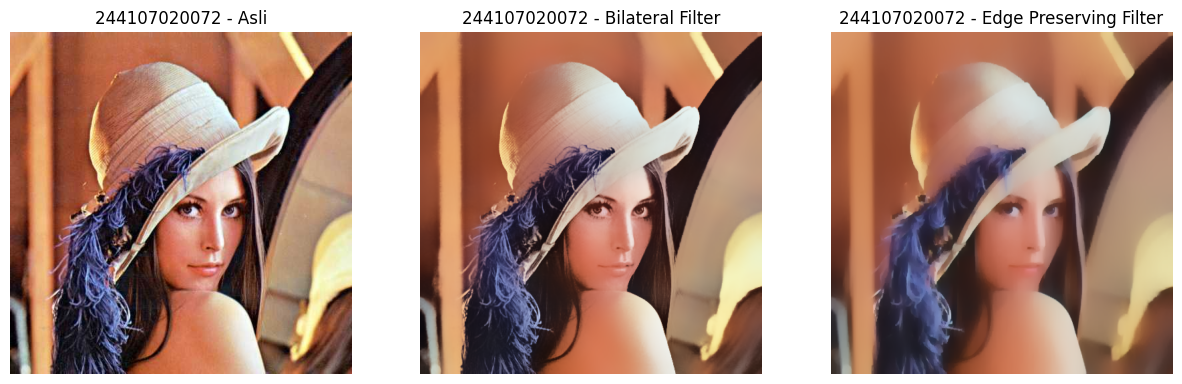

In [39]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                   ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

### Percobaan 3

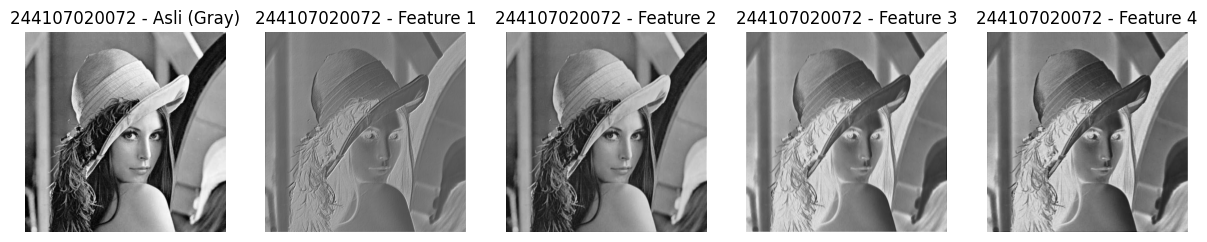

In [40]:
#Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

### Percobaan 4

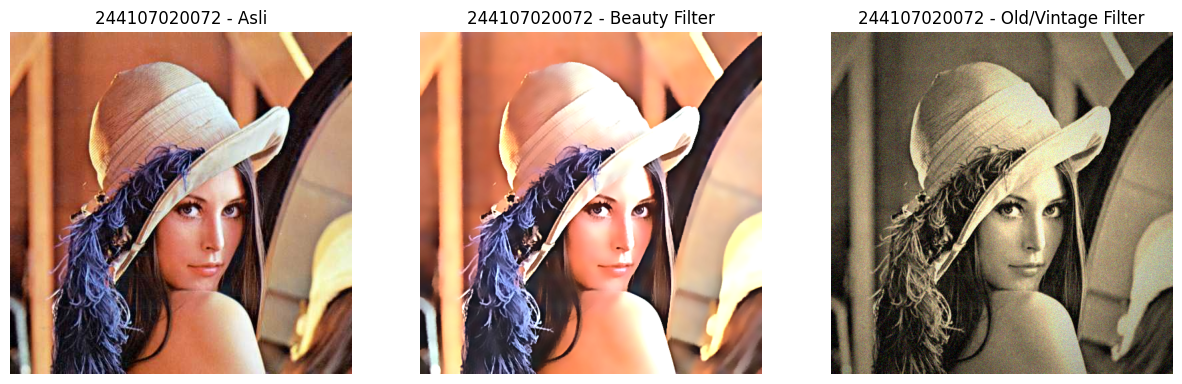

In [41]:
# ======================
# 1. Beauty Filter
# ======================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ======================
# 2. Old/Vintage Filter
# ======================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                          [0.349, 0.686, 0.168],
                          [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

### Percobaan 5

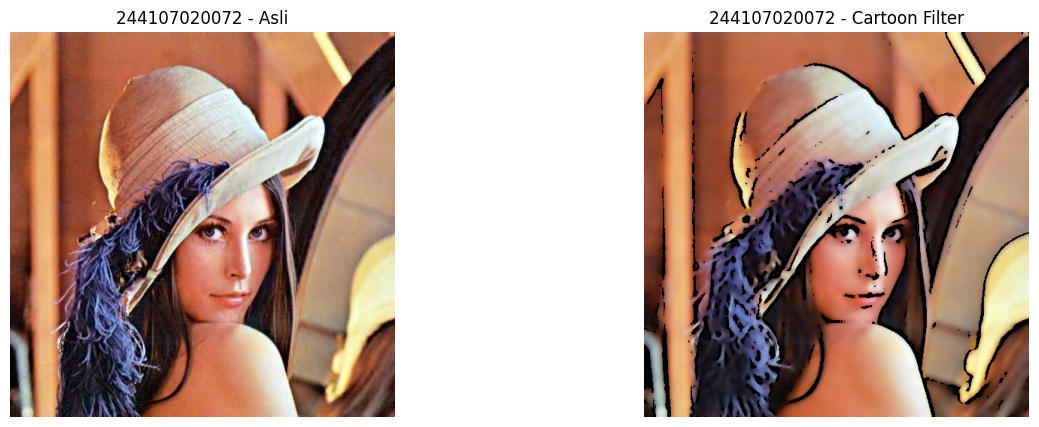

In [42]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                              cv.ADAPTIVE_THRESH_MEAN_C,
                              cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

### Percobaan 6

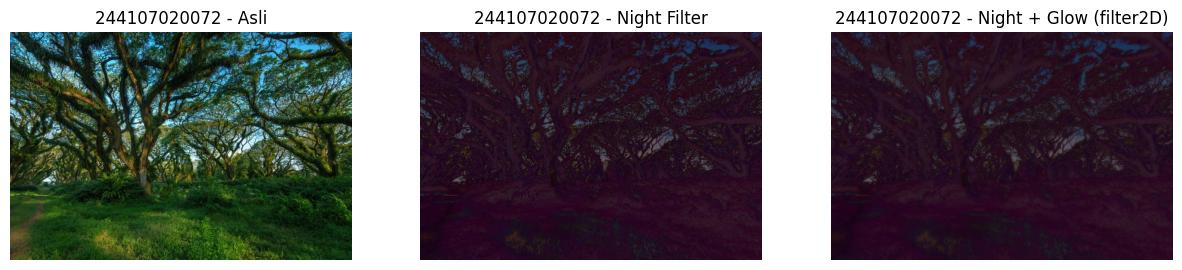

In [43]:
#Night Filter
img_night = cv.imread("/content/drive/MyDrive/PCVK/Images/244107020072/djawatan.jpg")
img_night_gray = cv.cvtColor(img_night, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img_night, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_night, night, night_glow],
                   ["Asli", "Night Filter", "Night + Glow (filter2D)"])

### Percobaan 7

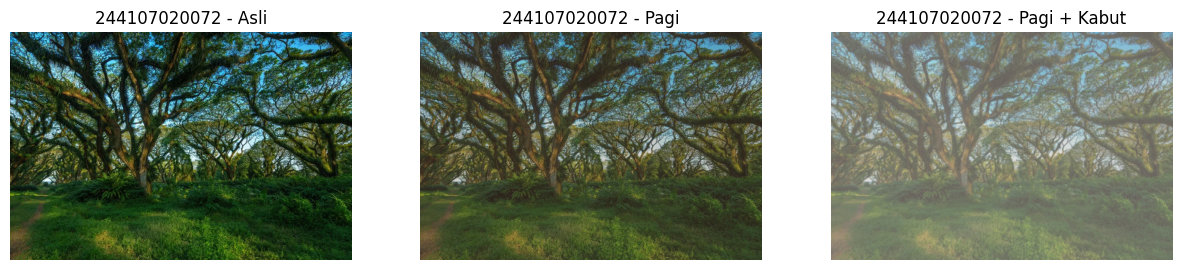

In [44]:
#Filter Suasana pagi dan Kabut
# =========================
# Step 1: Kurangi kontras & cerahkan
# =========================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img_night, alpha=alpha, beta=beta)

# =========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_night, pagi, kabut],
                   ["Asli", "Pagi", "Pagi + Kabut"])

# Tugas praktikum

1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper” <br>
a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).<br>
b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).<br>


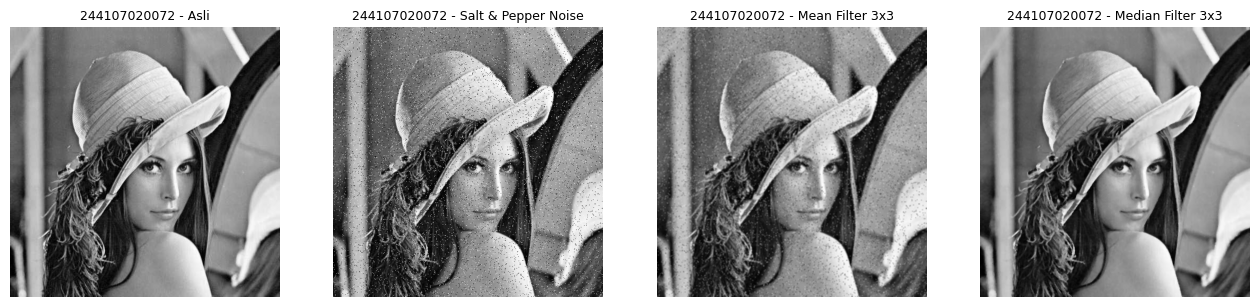

In [45]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020072/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# a. Tambahkan noise salt and pepper
noisy = img_gray.copy()
prob = 0.05
rnd = np.random.rand(*noisy.shape)
noisy[rnd < prob/2] = 0
noisy[rnd > 1 - prob/2] = 255

# b. Mean filter & Median filter 3x3
mean_filtered = cv.blur(noisy, (3,3))
median_filtered = cv.medianBlur(noisy, 3)

plt.figure(figsize=(16,5))
judul = ['Asli', 'Salt & Pepper Noise', 'Mean Filter 3x3', 'Median Filter 3x3']
citra = [img_gray, noisy, mean_filtered, median_filtered]
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 4, i)
    plt.imshow(c, cmap='gray')
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.<br>
jawab:<br>
Mean filter menghitung rata-rata seluruh piksel tetangga, sehingga nilai ekstrim (0 atau 255) dari noise tetap ikut mempengaruhi hasil rata-rata, menyebabkan noise hanya tersebar/kabur. Median filter mengambil nilai tengah dari piksel tetangga yang diurutkan, sehingga nilai ekstrim noise akan dibuang selama jumlah piksel noise tidak mendominasi jendela filter. Hasilnya noise benar-benar hilang tanpa mengaburkan tepi citra.



---



2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)<br>
a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.<br>
b. Terapkan pada citra yang sedikit buram (blurry).<br>


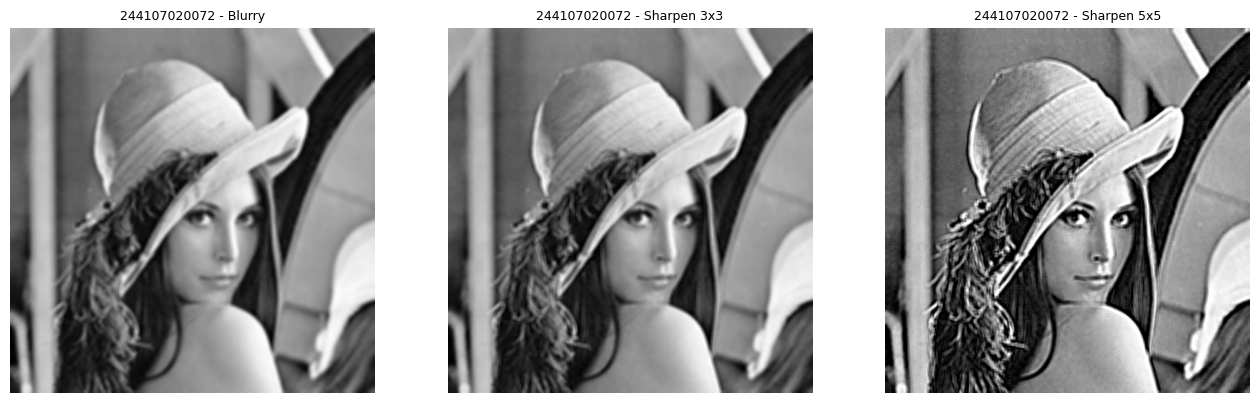

In [46]:
# a. Citra blurry
blurry = cv.GaussianBlur(img_gray, (7,7), 3)

# Sharpening kernel 3x3
kernel_3x3 = np.array([[0,-1,0],
                        [-1,5,-1],
                        [0,-1,0]])

# Sharpening kernel 5x5
kernel_5x5 = np.array([[0, 0,-1, 0, 0],
                        [0,-1,-2,-1, 0],
                        [-1,-2,17,-2,-1],
                        [0,-1,-2,-1, 0],
                        [0, 0,-1, 0, 0]])

sharp_3x3 = cv.filter2D(blurry, -1, kernel_3x3)
sharp_5x5 = cv.filter2D(blurry, -1, kernel_5x5)

plt.figure(figsize=(16,5))
judul = ['Blurry', 'Sharpen 3x3', 'Sharpen 5x5']
citra = [blurry, sharp_3x3, sharp_5x5]
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 3, i)
    plt.imshow(c, cmap='gray')
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.<br>
jawab: <br>
Kernel 3x3 memberikan penajaman tepi yang moderat dengan noise distortion minimal karena hanya melibatkan piksel tetangga langsung. Kernel 5x5 menghasilkan tepi yang jauh lebih tajam karena jangkauan area penguatan lebih luas, namun juga lebih rentan memperkuat noise dan artefak (ringing) di sekitar tepi. Untuk penggunaan sehari-hari, kernel 3x3 lebih optimal karena hasil lebih natural dan noise distortion lebih terkendali, sedangkan 5x5 cocok dipakai bila dibutuhkan penajaman ekstra pada citra yang sangat buram.



---



3. Tugas Kreasi: Filter Kartun Sederhana<br>
a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:<br>
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.<br>
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.<br>
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.<br><br>
b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

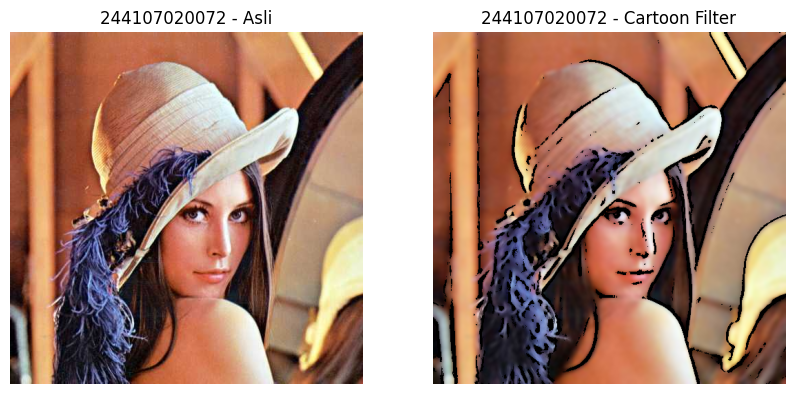

In [47]:
def kartun(image):
    # Penghalusan warna dengan Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # Deteksi garis tepi dengan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                  cv.ADAPTIVE_THRESH_MEAN_C,
                                  cv.THRESH_BINARY, 9, 9)

    # Gabungkan dengan operasi perkalian piksel (bitwise_and)
    hasil = cv.bitwise_and(color, color, mask=edges)
    return hasil

# menampilkan gambar
cartoon_img = kartun(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Asli'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv.cvtColor(cartoon_img, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Cartoon Filter'); plt.axis('off')
plt.show()